In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
import matplotlib.pyplot as plt
warnings.simplefilter(action="ignore",category=FutureWarning)

In [3]:
df = pd.read_csv("./dataset/fitness.csv")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            1790 non-null   float64
 1   Gender                         1729 non-null   object 
 2   Weight (kg)                    1778 non-null   float64
 3   Height (m)                     1774 non-null   float64
 4   Max_BPM                        1779 non-null   object 
 5   Avg_BPM                        1770 non-null   float64
 6   Resting_BPM                    1781 non-null   float64
 7   Session_Duration (hours)       1777 non-null   float64
 8   Calories_Burned                1777 non-null   float64
 9   Workout_Type                   1739 non-null   object 
 10  Fat_Percentage                 1784 non-null   float64
 11  Water_Intake (liters)          1776 non-null   float64
 12  Workout_Frequency (days/week)  1742 non-null   f

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,34.0,Female,86.7,1.86,174,152.0,74.0,1.12,712.0,Strength,12.8,2.4,5.0,2.0,14.31
1,26.0,Female,84.7,1.83,166,156.0,73.0,1.00,833.0,Strength,27.9,2.8,5.0,2.0,33.49
2,22.0,Male,64.8,1.85,187,166.0,64.0,1.24,1678.0,Cardio,28.7,1.9,3.0,2.0,12.73
3,54.0,Female,75.3,1.82,187,169.0,58.0,1.45,628.0,Cardio,31.8,2.4,4.0,1.0,20.37
4,34.0,Female,52.8,1.74,177,169.0,66.0,1.60,1286.0,Strength,26.4,3.2,4.0,2.0,20.83


In [55]:
df["BMI"].max()

np.float64(49.84)

In [73]:
df["Gender"].unique()

array(['Female', 'Male', nan], dtype=object)

In [65]:
x = sorted(df["BMI"].unique())
x[:10]

[np.float64(12.32),
 np.float64(12.33),
 np.float64(12.34),
 np.float64(12.35),
 np.float64(12.36),
 np.float64(12.37),
 np.float64(12.38),
 np.float64(12.4),
 np.float64(12.41),
 np.float64(12.46)]

In [51]:
for x in df.index:
    if(df.loc[x,"Workout_Frequency (days/week)"] == 2.0):
        df.loc[x,"Workout_Frequency (days/week)"] = 2

In [68]:
df.corr()

ValueError: could not convert string to float: 'Female'

In [70]:
new_df = df.select_dtypes(exclude="object")
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            1790 non-null   float64
 1   Weight (kg)                    1778 non-null   float64
 2   Height (m)                     1774 non-null   float64
 3   Avg_BPM                        1770 non-null   float64
 4   Resting_BPM                    1781 non-null   float64
 5   Session_Duration (hours)       1777 non-null   float64
 6   Calories_Burned                1777 non-null   float64
 7   Fat_Percentage                 1784 non-null   float64
 8   Water_Intake (liters)          1776 non-null   float64
 9   Workout_Frequency (days/week)  1742 non-null   float64
 10  Experience_Level               1743 non-null   float64
 11  BMI                            1770 non-null   float64
dtypes: float64(12)
memory usage: 168.9 KB


In [4]:
group = df.groupby(df.Gender)
group.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,34.0,Female,86.7,1.86,174,152.0,74.0,1.12,712.0,Strength,12.8,2.4,5.0,2.0,14.31
1,26.0,Female,84.7,1.83,166,156.0,73.0,1.00,833.0,Strength,27.9,2.8,5.0,2.0,33.49
2,22.0,Male,64.8,1.85,187,166.0,64.0,1.24,1678.0,Cardio,28.7,1.9,3.0,2.0,12.73
3,54.0,Female,75.3,1.82,187,169.0,58.0,1.45,628.0,Cardio,31.8,2.4,4.0,1.0,20.37
4,34.0,Female,52.8,1.74,177,169.0,66.0,1.60,1286.0,Strength,26.4,3.2,4.0,2.0,20.83
5,38.0,Female,53.0,1.58,161,128.0,74.0,1.62,953.0,HIIT,23.4,2.5,2.0,2.0,13.02
11,46.0,Male,40.0,1.88,168,131.0,69.0,2.00,672.0,NaN,25.4,2.4,2.0,2.0,12.32
12,19.0,Male,87.7,1.98,186,145.0,50.0,1.61,1705.0,Strength,14.1,2.3,3.0,2.0,15.99
16,23.0,Male,56.2,1.76,195,141.0,55.0,1.45,1195.0,HIIT,23.9,3.2,4.0,1.0,22.61
19,NaN,Male,63.0,1.51,184,169.0,71.0,1.30,1136.0,Cardio,23.8,2.3,3.0,2.0,22.69


In [5]:
male_df = group.get_group("Male")
male_df["Gender"].unique()

array(['Male'], dtype=object)

In [84]:
male_new = male_df.select_dtypes(exclude="object")
male_new.info()
male_new.corr()

<class 'pandas.core.frame.DataFrame'>
Index: 857 entries, 2 to 1799
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            852 non-null    float64
 1   Weight (kg)                    847 non-null    float64
 2   Height (m)                     843 non-null    float64
 3   Avg_BPM                        842 non-null    float64
 4   Resting_BPM                    850 non-null    float64
 5   Session_Duration (hours)       844 non-null    float64
 6   Calories_Burned                848 non-null    float64
 7   Fat_Percentage                 849 non-null    float64
 8   Water_Intake (liters)          848 non-null    float64
 9   Workout_Frequency (days/week)  833 non-null    float64
 10  Experience_Level               829 non-null    float64
 11  BMI                            841 non-null    float64
dtypes: float64(12)
memory usage: 87.0 KB


,Age,Weight (kg),Height (m),Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
Age,1.000000,0.006062,-0.003130,0.013980,0.008272,0.015181,-0.069778,-0.030791,-0.048759,0.019449,0.017011,0.056093
Weight (kg),0.006062,1.000000,-0.076576,0.079876,-0.006653,-0.010066,-0.011691,0.014421,-0.022363,-0.054752,-0.056244,0.048571
Height (m),-0.003130,-0.076576,1.000000,-0.042468,-0.018105,0.042938,0.035670,-0.018081,-0.034939,-0.008996,-0.022029,0.020956
Avg_BPM,0.013980,0.079876,-0.042468,1.000000,-0.053362,0.062820,0.078087,-0.015719,0.023281,-0.029050,0.021981,-0.022138
Resting_BPM,0.008272,-0.006653,-0.018105,-0.053362,1.000000,0.002749,-0.114299,-0.082948,0.018906,-0.004318,0.012975,0.037814
Session_Duration (hours),0.015181,-0.010066,0.042938,0.062820,0.002749,1.000000,0.038255,0.012293,-0.069722,0.062365,-0.044421,0.036563
Calories_Burned,-0.069778,-0.011691,0.035670,0.078087,-0.114299,0.038255,1.000000,0.037701,0.016642,0.067493,-0.034067,-0.048122
Fat_Percentage,-0.030791,0.014421,-0.018081,-0.015719,-0.082948,0.012293,0.037701,1.000000,-0.004683,-0.077512,0.040691,0.025388
Water_Intake (liters),-0.048759,-0.022363,-0.034939,0.023281,0.018906,-0.069722,0.016642,-0.004683,1.000000,-0.039785,0.041710,-0.023386
Workout_Frequency (days/week),0.019449,-0.054752,-0.008996,-0.029050,-0.004318,0.062365,0.067493,-0.077512,-0.039785,1.000000,-0.074860,-0.008541


In [10]:
plt.figure(figsize=(100,100))

<Figure size 10000x10000 with 0 Axes>

<Figure size 10000x10000 with 0 Axes>

<Axes: >

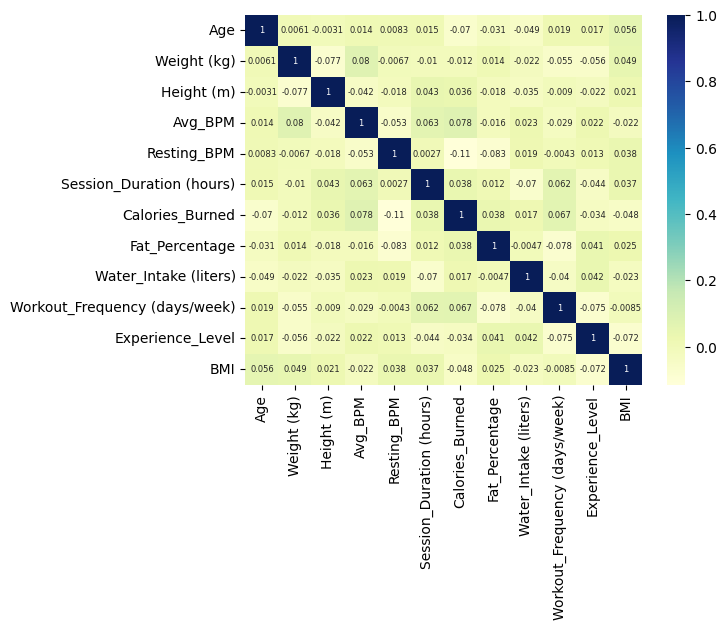

In [19]:
sns.heatmap(male_df.corr(numeric_only = True), cmap="YlGnBu", annot=True,annot_kws={"size":6})


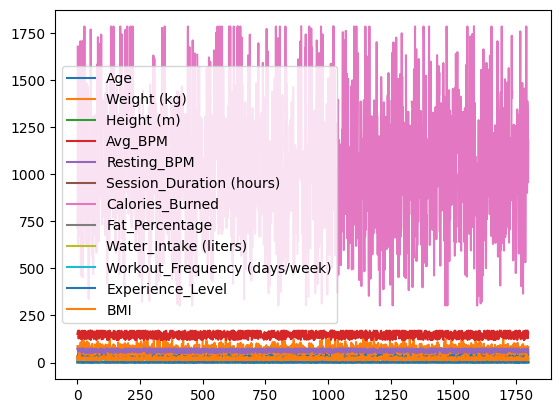

In [20]:
df.plot()
plt.show()